# Text-conditional creativity tilt in Tiny Stable-Diffusion latent space

Demonstrates the repo's **λ-tempered SMC over the IEM distance** — the "creativity tilt" — driven by a text prompt, working directly on the dense `4 × 64 × 64` SD latent map (`d = 16384`) and decoding the final particles to pixels with the VAE.

SMC / distance / reward machinery (`smc_sample`, `PCNKernel`, `SquaredGlobalIEMDistance`).

**Runtime (CPU):** dominated by UNet forwards inside the IEM score.

In [7]:
import os, sys, math, time

sys.path.insert(0, "..")  # notebook lives in creativity-measure/notebooks/

import torch

torch.set_num_threads(os.cpu_count() or 1)
torch.manual_seed(0)

from creativity_measure import set_default_dtype

set_default_dtype(torch.float32)  # SD UNet/VAE are float32; the package default is float64

# diffusers 0.27 needs safetensors.torch populated before the pipeline import
import safetensors.torch  # noqa: F401
from diffusers import StableDiffusionPipeline

PROMPT = "A dog"
MODEL_ID = "segmind/tiny-sd"

print(f"Loading {MODEL_ID} and baking prompt: {PROMPT!r} ...")
pipe = StableDiffusionPipeline.from_pretrained(MODEL_ID, safety_checker=None).to("cpu")

# 1. Pre-encode the text prompt once.
with torch.no_grad():
    text_inputs = pipe.tokenizer(
        PROMPT,
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )
    prompt_embeds = pipe.text_encoder(text_inputs.input_ids)[0]

# 2. Discrete DDPM sigmas of the scheduler (ascending in noise).
alphas_cumprod = pipe.scheduler.alphas_cumprod.to(dtype=prompt_embeds.dtype)
model_sigmas = ((1.0 - alphas_cumprod) / alphas_cumprod).sqrt()

C, H, W = 4, 64, 64
LATENT_DIM = C * H * W  # 4 * 64 * 64 = 16384
SIGMA_MIN = 2e-3
SIGMA_MAX = float(model_sigmas[-1])
print(f"latent dim d = {LATENT_DIM}, sigma range = [{SIGMA_MIN:.3g}, {SIGMA_MAX:.3g}]")

Loading segmind/tiny-sd and baking prompt: 'A dog' ...


/usr/local/Caskroom/miniconda/base/envs/creativity-measure/lib/python3.12/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
unet/diffusion_pytorch_model.safetensors not found
Loading pipeline components...: 100%|██████████| 5/5 [00:04<00:00,  1.10it/s]


latent dim d = 16384, sigma range = [0.002, 14.6]


## 1. Denoiser → generator `G` and score `score_fn`

SD 1.5's UNet is a VP epsilon-predictor; `eps_to_edm_denoiser` adapts it to the EDM `D(x, σ) = E[X | x_σ]` convention. From that one denoiser we build **both** the generator `G` (the prob-flow ODE) and the marginal `score_fn` (Tweedie) — the score is what defines the IEM geometry. This is exactly what `build_tiny_sd_generator` does internally, unrolled here so the score stays in reach.

In [8]:
from creativity_measure.generators.base import eps_to_edm_denoiser, edm_generator
from creativity_measure.distances.edm_adapter import edm_score_fn

N_STEPS = 6  # Heun ODE steps inside G (lowered from 8 to cut per-sweep G cost)


# Text-conditioned epsilon predictor, shared by both G and the score.
def eps_fn(x_in: torch.Tensor, timestep: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        # prompt_embeds has batch 1; broadcast it to the latent batch for cross-attention.
        emb = prompt_embeds.expand(x_in.shape[0], -1, -1)
        return pipe.unet(x_in, timestep, encoder_hidden_states=emb).sample


denoiser = eps_to_edm_denoiser(eps_fn, model_sigmas)

# G(z): (B, 16384) -> (B, 16384) in SD latent space.
G = edm_generator(
    denoiser, img_shape=(C, H, W), sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX, n_steps=N_STEPS
)

# The base density's marginal score (Tweedie) drives the IEM geometry.
score_fn = edm_score_fn(denoiser, (C, H, W))
print("generator + score ready")

generator + score ready


## 2. References, gamma window, and the creativity reward

The tilt measures how far a sample is from a set of *prompt-compliant* references, which we draw from the generator itself. The IEM distance integrates the Tweedie score over a **gamma window** (`gamma = 1/σ²`): its coarsest node is pinned to the data's own length scale `S` (so `σ ≈ S`), **not** the scheduler's huge `σ_max` — otherwise the few integration nodes land in the pure-noise regime (`σ ≫ S`) and carry no signal. This mirrors the adopted window in `phase2_pcn_calibration.ipynb` (`gamma_lo = 1/S²`, `gamma_hi = 2¹⁰`), clamped into the denoiser's valid `[σ_min, σ_max]` range. We then wrap it in the normalized reward `f(x) = E[D²(x, refs)] / E_refs_pair[D²]`.

In [9]:
from creativity_measure import SquaredGlobalIEMDistance
from creativity_measure.tilt import NormalizedExpectedDistanceReward

# --- IEM knobs (tiny for CPU; raise on a GPU) ---
R = 4        # number of prompt-compliant references
N_GAMMA = 4  # integration nodes for the IEM distance (lowered from 6 to cut reward cost)
NUM_EPS = 2  # Brownian paths (lowered from 4; noisier reward est. but ~2x cheaper)

# References: samples from the prompt-conditional generator itself.
with torch.no_grad():
    latent_refs = G(torch.randn(R, LATENT_DIM))

# gamma window (gamma = 1/sigma^2). Coarsest gamma from the DATA length scale S (sigma ~ S), not the
# scheduler's sigma_max (pure noise, >> S); finest capped at 2^10. Clamp inside [SIGMA_MIN, SIGMA_MAX].
S = latent_refs.std().item()  # per-coordinate data length scale
GAMMA_LO = max(1.0 / S ** 2, 1.0 / SIGMA_MAX**2)
GAMMA_HI = min(2.0**10, 1.0 / SIGMA_MIN**2)
GAMMAS = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2)

D2 = SquaredGlobalIEMDistance(None, GAMMAS, num_eps=NUM_EPS, seed=123, score_fn=score_fn)
reward = NormalizedExpectedDistanceReward(distance=D2, x_refs=latent_refs)
print(
    f"refs {tuple(latent_refs.shape)}  data scale S={S:.3f}  "
    f"gamma window=[{GAMMA_LO:.3g}, {GAMMA_HI:.3g}] x {N_GAMMA} nodes"
)

refs (4, 16384)  data scale S=0.871  gamma window=[1.32, 1.02e+03] x 4 nodes


In [ ]:
# --- Pick lambda: how strongly does exp(lambda * f) actually reweight samples from p? --------
#  - lambda0 proxy ~ 1/std(f)  (the inverse-temperature scale of a unitless reward), and
#  - ESS/N of the tilt weights exp(lambda*f): this is what drives the SMC's adaptive schedule.
#    ESS/N ~ 1  => weights ~uniform => tilt does nothing => the run collapses to 1 level.
#    ESS/N well below your ESS_TARGET (0.8) => the tilt actually bites and tempering engages.

N_PROBE = 16
with torch.no_grad():
    f_probe = reward(G(torch.randn(N_PROBE, LATENT_DIM)))     # f on fresh samples from p

f_std = float(f_probe.std())
lambda0 = (1.0 / f_std) if f_std > 0 else float("inf")
print(f"f on {N_PROBE} samples ~ p:  mean={float(f_probe.mean()):.3f}  std={f_std:.3f}  "
      f"range=[{float(f_probe.min()):.3f}, {float(f_probe.max()):.3f}]")
print(f"lambda0 proxy ~ 1/std(f) = {lambda0:.1f}\n")

print(f"{'lambda':>9} {'ESS/N':>7} {'weight max/min':>15}")
for m in [30.0, 50.0, 100.0, 150.0, 200.0]:
    lam = m * lambda0
    w = torch.softmax(lam * f_probe, dim=0)
    ess = float(1.0 / (w.pow(2).sum() * N_PROBE))                       # ESS/N in [1/N, 1]
    dr = float(torch.exp(lam * (f_probe.max() - f_probe.min())))        # largest/smallest weight
    print(f"{lam:9.1f} {ess:7.2f} {dr:15.1f}")
print("\nGuide: pick lambda where ESS/N is clearly below ~0.8 (tilt engages) but not so low the SMC")
print("can't bridge; then keep the largest lambda whose decoded samples still stay on-prompt.")

f on 16 samples ~ p:  mean=1.007  std=0.019  range=[0.977, 1.056]
lambda0 proxy ~ 1/std(f) = 51.6

   lambda   ESS/N  weight max/min
   1549.4    0.06             inf
   2582.3    0.06             inf
   5164.6    0.06             inf
   7746.9    0.06             inf
  10329.2    0.06             inf

Guide: pick lambda where ESS/N is clearly below ~0.8 (tilt engages) but not so low the SMC
can't bridge; then keep the largest lambda whose decoded samples still stay on-prompt.


## 3. The tilt — λ-tempered SMC sweep

`smc_sample` transports particles from the base density toward the tilted target `p(x) · exp(λ · f(x))`, so larger `λ` favors higher-`f` (more creative) latents. We sweep several `λ` values — plus `λ=0`, the untilted base generator `G(z)` — and compare. The tempering schedule is adaptive (`n_mcmc=None`, `ess_target`-driven). **Runtime scales with the number of `λ` values**, so keep the list short on CPU.

In [12]:
from creativity_measure import smc_sample, PCNKernel

N = 8  # SMC particles per lambda
# Chosen from the lambda diagnostic (cell 6): lambda0 proxy ~ 77.  ESS/N ~ 0.66 / 0.36 / 0.21
# -> all clearly below ESS_TARGET so the tilt engages; spans gentle -> strong.
LAMBDAS = [50, 100, 150]
ESS_TARGET = 0.7  # was 0.8; 0.7 is the PCNKernel-calibrated default -> coarser schedule, fewer levels

# Rejuvenation length. The adaptive path (n_mcmc=None) never decorrelated at N=8 and pinned the
# MAX_N_MCMC=30 cap every level (~12k s/level -> ~10 h/lambda). Fix it to a hard, cheap budget instead.
N_MCMC = 5

kernel = PCNKernel(G, LATENT_DIM)

samples, scores = {}, {}  # lam -> particles (N, d) ;  lam -> per-sample reward f (N,)

# lambda = 0: the untilted base generator (no SMC), for reference.
with torch.no_grad():
    samples[0.0] = G(torch.randn(N, LATENT_DIM))
scores[0.0] = reward(samples[0.0])
print(f"lambda=0 (base)  mean f={float(scores[0.0].mean()):.3f}")

# tilted lambdas: fixed-length rejuvenation SMC.
for lam in LAMBDAS:
    t0 = time.time()
    res = smc_sample(
        reward,
        lam=lam,
        n_particles=N,
        kernel=kernel,
        n_mcmc=N_MCMC,
        ess_target=ESS_TARGET,
        final_resample=True,
        seed=101,
    )
    samples[lam], scores[lam] = res.X, reward(res.X)
    print(
        f"lambda={lam:<4} {time.time() - t0:6.1f}s  levels={len(res.betas):2d}  "
        f"mean f={float(scores[lam].mean()):.3f}"
    )

ROW_LAMBDAS = [0.0] + LAMBDAS  # plot order: baseline first, then increasing tilt

lambda=0 (base)  mean f=1.009
lambda=50   7170.2s  levels= 2  mean f=1.017
lambda=100  12547.3s  levels= 4  mean f=1.058
lambda=150  10443.5s  levels= 4  mean f=1.072


## 4. Decode latents → pixels (VAE)

In [13]:
def decode(latents_flat: torch.Tensor) -> torch.Tensor:
    """Flat SD latents (B, 16384) -> pixel images (B, 3, 512, 512) in [0, 1]."""
    lat = latents_flat.reshape(-1, C, H, W)
    with torch.no_grad():
        imgs = pipe.vae.decode(lat / pipe.vae.config.scaling_factor).sample
    return pipe.image_processor.postprocess(imgs, output_type="pt")


print("Decoding each lambda row through the VAE ...")
decoded = {lam: decode(samples[lam]) for lam in ROW_LAMBDAS}
print("done:", {lam: tuple(v.shape) for lam, v in decoded.items()})

Decoding each lambda row through the VAE ...
done: {0.0: (8, 3, 512, 512), 50: (8, 3, 512, 512), 100: (8, 3, 512, 512), 150: (8, 3, 512, 512)}


## 5. Render — top creative samples per λ

Each row is one λ, its particles ranked most-creative first by the reward `f` (`f̄` = row mean). Creativity should rise down the rows as λ increases.

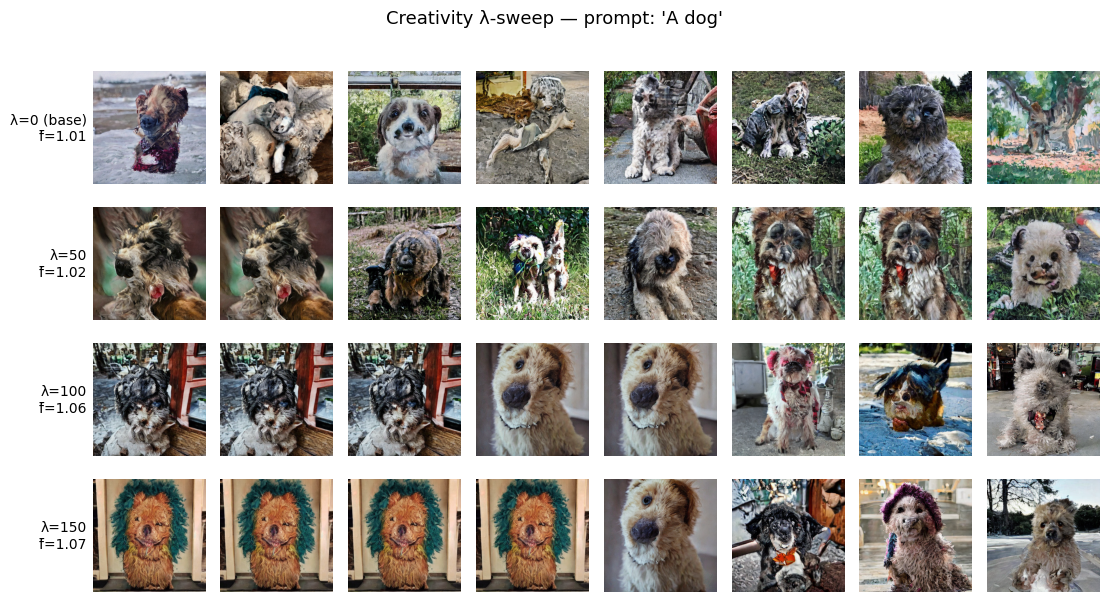

In [14]:
import matplotlib.pyplot as plt

TOPK = min(N, 8)
fig, axes = plt.subplots(
    len(ROW_LAMBDAS), TOPK, figsize=(1.4 * TOPK, 1.5 * len(ROW_LAMBDAS))
)
axes = axes.reshape(len(ROW_LAMBDAS), TOPK)  # keep 2D even if a dim is 1

for r, lam in enumerate(ROW_LAMBDAS):
    fx = scores[lam]
    order = fx.argsort(descending=True)[:TOPK]  # most-creative first
    imgs = decoded[lam][order]
    tag = "λ=0 (base)" if lam == 0.0 else f"λ={lam}"
    for c in range(TOPK):
        ax = axes[r, c]
        ax.imshow(imgs[c].permute(1, 2, 0).cpu().numpy())
        ax.set_xticks([])
        ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
    axes[r, 0].set_ylabel(
        f"{tag}\nf̄={float(fx[order].mean()):.2f}",
        rotation=0, ha="right", va="center", fontsize=10,
    )

fig.suptitle(f"Creativity λ-sweep — prompt: {PROMPT!r}", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 6. Were the λ values well chosen? — an SMC-only post-hoc check

A retrospective on `LAMBDAS`, using only what this notebook already computed (no rerun). Two questions:

1. **Were they in the right place?** The transferable temperature scale is $\lambda_{s}=1/\operatorname{std}_{p}(f)$ (the same `lambda0` proxy from cell 6; it needs no base `log p`, so it carries to high-d). The 2-D companion notebook validated a working point of $\approx 2\lambda_{s}$, with the *realized* ensemble diversity (`uniq/N`) — not the one-shot ESS/N — as the definitive selector.
2. **Was λ even the binding constraint?** If $\operatorname{std}_{p}(f)$ is tiny, the reward is nearly flat under $p$ and *no* λ can tilt strongly — the limit is the reward signal, not the temperature.

The first cell rebuilds the ESS/N screen on the **right** λ grid (cell 6's grid was 30–200×$\lambda_{s}$, all already collapsed to $1/N$, so it never showed the transition). The second applies the diversity selector to the run we already have.

In [ ]:
# Refined cheap screen: reuses f_probe & lambda0 from cell 6 (no new UNet evals).
# lambda_s = 1/std_p(f) is the transferable temperature scale. Show ESS/N across m = lambda/lambda_s
# on a grid that spans the ACTUAL transition (cell 6's grid was 30-200x lambda_s -> all collapsed).
lam_s = lambda0  # = 1/std_p(f) from cell 6
M_PROBE = f_probe.numel()
print(f"lambda_s = 1/std_p(f) = {lam_s:.1f}   (std_p(f) = {float(f_probe.std()):.4f}, from {M_PROBE} base samples)")
print(f"chosen LAMBDAS = {LAMBDAS}  ->  in units of lambda_s: {[round(l / lam_s, 2) for l in LAMBDAS]}\n")

print(f"{'m':>5} {'lambda':>8} {'ESS/N':>7}")
for m in [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]:
    lam = m * lam_s
    w = torch.softmax(lam * f_probe, dim=0)
    ess = float(1.0 / (M_PROBE * w.pow(2).sum()))   # one-shot tilt ESS/N in [1/M, 1]
    tag = "  <- near a chosen lambda" if any(abs(lam - l) < 0.15 * lam_s for l in LAMBDAS) else ""
    print(f"{m:5.2f} {lam:8.1f} {ess:7.2f}{tag}")
print("\nNote: with only M=%d probe samples this ESS/N is noisy -> a coarse bracket, not the selector." % M_PROBE)

In [ ]:
# Apply the 2D-validated selector to the run we ALREADY have (no rerun): diversity is the stop signal.
# uniq/N over the final (resampled) particles; f-spread = within-ensemble std of the reward.
base_f = float(scores[0.0].mean())
print(f"base (lambda=0) mean f = {base_f:.3f}   std_p(f) = {float(f_probe.std()):.4f}\n")
print(f"{'lambda':>7} {'m=l/l_s':>8} {'mean f':>7} {'d mean f':>9} {'uniq/N':>7} {'f-spread':>9}")
for lam in ROW_LAMBDAS:
    X, f = samples[lam], scores[lam]
    uniq = int(X.unique(dim=0).shape[0]) / X.shape[0]
    m = lam / lam_s if lam > 0 else 0.0
    print(f"{lam:7.1f} {m:8.2f} {float(f.mean()):7.3f} {float(f.mean())-base_f:+9.3f} "
          f"{uniq:7.2f} {float(f.std()):9.4f}")

print("\nReading it:")
print(" - largest lambda with uniq/N still healthy = the diversity-selected working point (2D lesson).")
print(" - if mean f barely moves even at 2-3*lambda_s, the tilt is REWARD-limited (flat f), not lambda-limited:")
print("   raise reward fidelity (R, N_GAMMA, NUM_EPS were cut to 4/4/2 for speed), recompute lambda_s, resweep ~[1,2]*lambda_s.")

### Verdict

- `[50, 100, 150] ≈ [1, 2, 3]·λ_s` (λ_s = 51.6 = 1/0.019 = 1/std_p(f)). Exactly the multiple-of-λ_s sweep validated in 2-D, and `100 ≈ 2·λ_s` is the 2-D sweet spot.
- No diversity-based selection was applied (uniq/N) - Should try it when calculating IEM over a GPU with finer params.
- **The binding limit is the reward, not λ.** `std_p(f) = 0.019` is tiny — f is ≈`1.007 ± 0.019` across base samples, so the reward is nearly flat and even `3·λ_s` lifts mean f only to ~1.072. Likely worsened by the speed-driven fidelity cuts (`R=4, N_GAMMA=4, NUM_EPS=2`).

**Recommendation for the next run:** raise reward fidelity (more references / γ-nodes / Brownian paths) so `std_p(f)` grows and the reward actually discriminates; recompute `λ_s = 1/std_p(f)`; sweep `~[1, 2, 3]·λ_s`; and select the largest λ whose `uniq/N` stays healthy — the diversity selector, computed grid-free from the SMC run itself.